In [1]:
from pathlib import Path
import sys
sys.set_int_max_str_digits(10000)
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
sys.path.append(str(Path.cwd().parents[1] / "code"))
from utils import open_graph, compute_ss_contact_probabilities

## Experiment setup + preprocessing

In [2]:
markov_graph = open_graph("markov_chain")
obj = compute_ss_contact_probabilities(
    markov_graph,
    4,
    precision=100,
)

Computing power sums:   0%|          | 0/12 [00:00<?, ?it/s]

Computing power sums:   0%|          | 0/12 [00:00<?, ?it/s]

## Run simulations

In [ ]:
# Import the Markov chain and compute stationary statistics.
markov_graph = open_graph("markov_chain")
obj = compute_ss_contact_probabilities(
    markov_graph,
    4,
    precision=100,
)

# Construct the physical graph corresponding to the Markov chain.
G = nx.Graph()
for node in markov_graph:
    neighbors = markov_graph[node][1]
    for node2 in neighbors:
        if node[0] != node2:
            G.add_edge(node[0], node2)

# Experiment parameters.
iterations = 10000
n_walkers = 8
seq_len = 30000

# Precompute transitions states.
state_keys = list(markov_graph.keys())
n_states = len(state_keys)
state_to_idx = {state: i for i, state in enumerate(state_keys)}
state_pos = np.array([state[-1] for state in state_keys])
cdf_list = []
next_state_list = []

for state in state_keys:
    probs, neighbors = markov_graph[state]
    probs = np.asarray(probs, dtype=np.float64)
    neighbors = np.asarray(neighbors)
    cdf = np.cumsum(probs)

    if not np.isclose(cdf[-1], 1.0):
        cdf = cdf / cdf[-1]

    next_states = [state[1:] + (nbr,) for nbr in neighbors]
    next_state_idx = np.array(
        [state_to_idx[s] for s in next_states],
        dtype=np.int32
    )
    cdf_list.append(cdf)
    next_state_list.append(next_state_idx)

# Simulate contacts between walkers.

tot_occurrence2 = np.zeros((3, seq_len), dtype=np.int64)
tot_joint_occurrence2 = np.zeros((3, seq_len - 1), dtype=np.int64)
num_occ2 = 0

for _ in tqdm(range(iterations)):
    occurrences = np.zeros((3, seq_len), dtype=np.int32)

    walker_states = np.random.randint(
        0,
        n_states,
        size=n_walkers,
        dtype=np.int32,
    )

    for step in range(seq_len):
        positions = state_pos[walker_states]
        p0 = positions[0]
        if p0 == positions[1]:
            occurrences[0, step] += 1
            if p0 == positions[2]:
                occurrences[1, step] += 1
                if p0 == positions[3]:
                    occurrences[2, step] += 1
        rand_vals = np.random.rand(n_walkers)
        new_states = np.empty_like(walker_states)

        for w, s in enumerate(walker_states):
            new_states[w] = next_state_list[s][
                np.searchsorted(cdf_list[s], rand_vals[w])
            ]

        walker_states = new_states

    joint_occurrences = occurrences[:, :-1] * occurrences[:, 1:]

    tot_occurrence2 += occurrences
    tot_joint_occurrence2 += joint_occurrences
    num_occ2 += 1


# Compute theoretical steady-state contact probabilities.
obj_prob = obj["prob"]
obj_joint_prob = obj["joint_prob"]


# Compute cumulative single-time contact probabilities.

cum = np.cumsum(tot_occurrence2, axis=1)
den = np.arange(1, seq_len + 1)

p_data2 = cum / (den * num_occ2)

v2 = np.array(
    [obj_prob[i + 2] for i in range(p_data2.shape[0])],
    dtype=float,
)[:, None]

rel_error2 = np.abs(p_data2 - v2) / v2


# Compute cumulative consecutive-time contact probabilities.

cum2 = np.cumsum(tot_joint_occurrence2, axis=1)
den2 = np.arange(1, seq_len)

p_data_joint2 = cum2 / (den2 * num_occ2)

v2_joint = np.array(
    [obj_joint_prob[i + 2] for i in range(p_data_joint2.shape[0])],
    dtype=float,
)[:, None]

rel_error_joint2 = np.abs(p_data_joint2 - v2_joint) / v2_joint

return (
    tot_occurrence2,
    num_occ2,
    tot_joint_occurrence2,
    seq_len,
    obj_prob,
    obj_joint_prob,
    rel_error2,
    rel_error_joint2
)

## Alternative: load precomputed results

In [4]:
(
    tot_occurrence2,
    num_occ2,
    tot_joint_occurrence2,
    seq_len,
    obj_prob,
    obj_joint_prob,
    rel_error2,
    rel_error_joint2
) = open_graph("contact_statistics")

## Vizualization

In [5]:
sns.set_theme(style="ticks", context="paper", palette="colorblind")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 20,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "legend.fontsize": 22,
    "legend.title_fontsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "lines.linewidth": 4,
    "axes.linewidth": 0.8
})


# Plot convergence of contact probabilities.
def plot_contact_convergence(rel_error, global_max, filename):
    colors = np.array(sns.color_palette("Set2"))[[0, 2, -1]]

    x = np.arange(1, min(30000, rel_error.shape[1]) + 1)

    labels = [
        "C = 2",
        "C = 3",
        "C = 4"
    ]

    fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

    for i in range(min(3, rel_error.shape[0])):
        ax.plot(
            x,
            rel_error[i, :len(x)],
            color=colors[i],
            label=labels[i]
        )

    ax.set_xlabel("Length of contact graph sequence ($K$)", fontsize=30)
    ax.set_ylabel("Relative error", fontsize=30)

    global_min = 0
    tick_size = 5000

    ax.grid(True, linestyle="--", alpha=0.25, linewidth=0.7)
    ax.legend(
        frameon=True,
        bbox_to_anchor=(1.005, 1.01),
        title=r"Group size, C"
    )
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(0, 1)

    plt.xticks(np.arange(0, global_max + 1, tick_size))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both")

    plt.tight_layout()

    plt.savefig(
        filename,
        bbox_inches="tight",
        dpi=300
    )

    plt.show()

### Single-time contacts

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

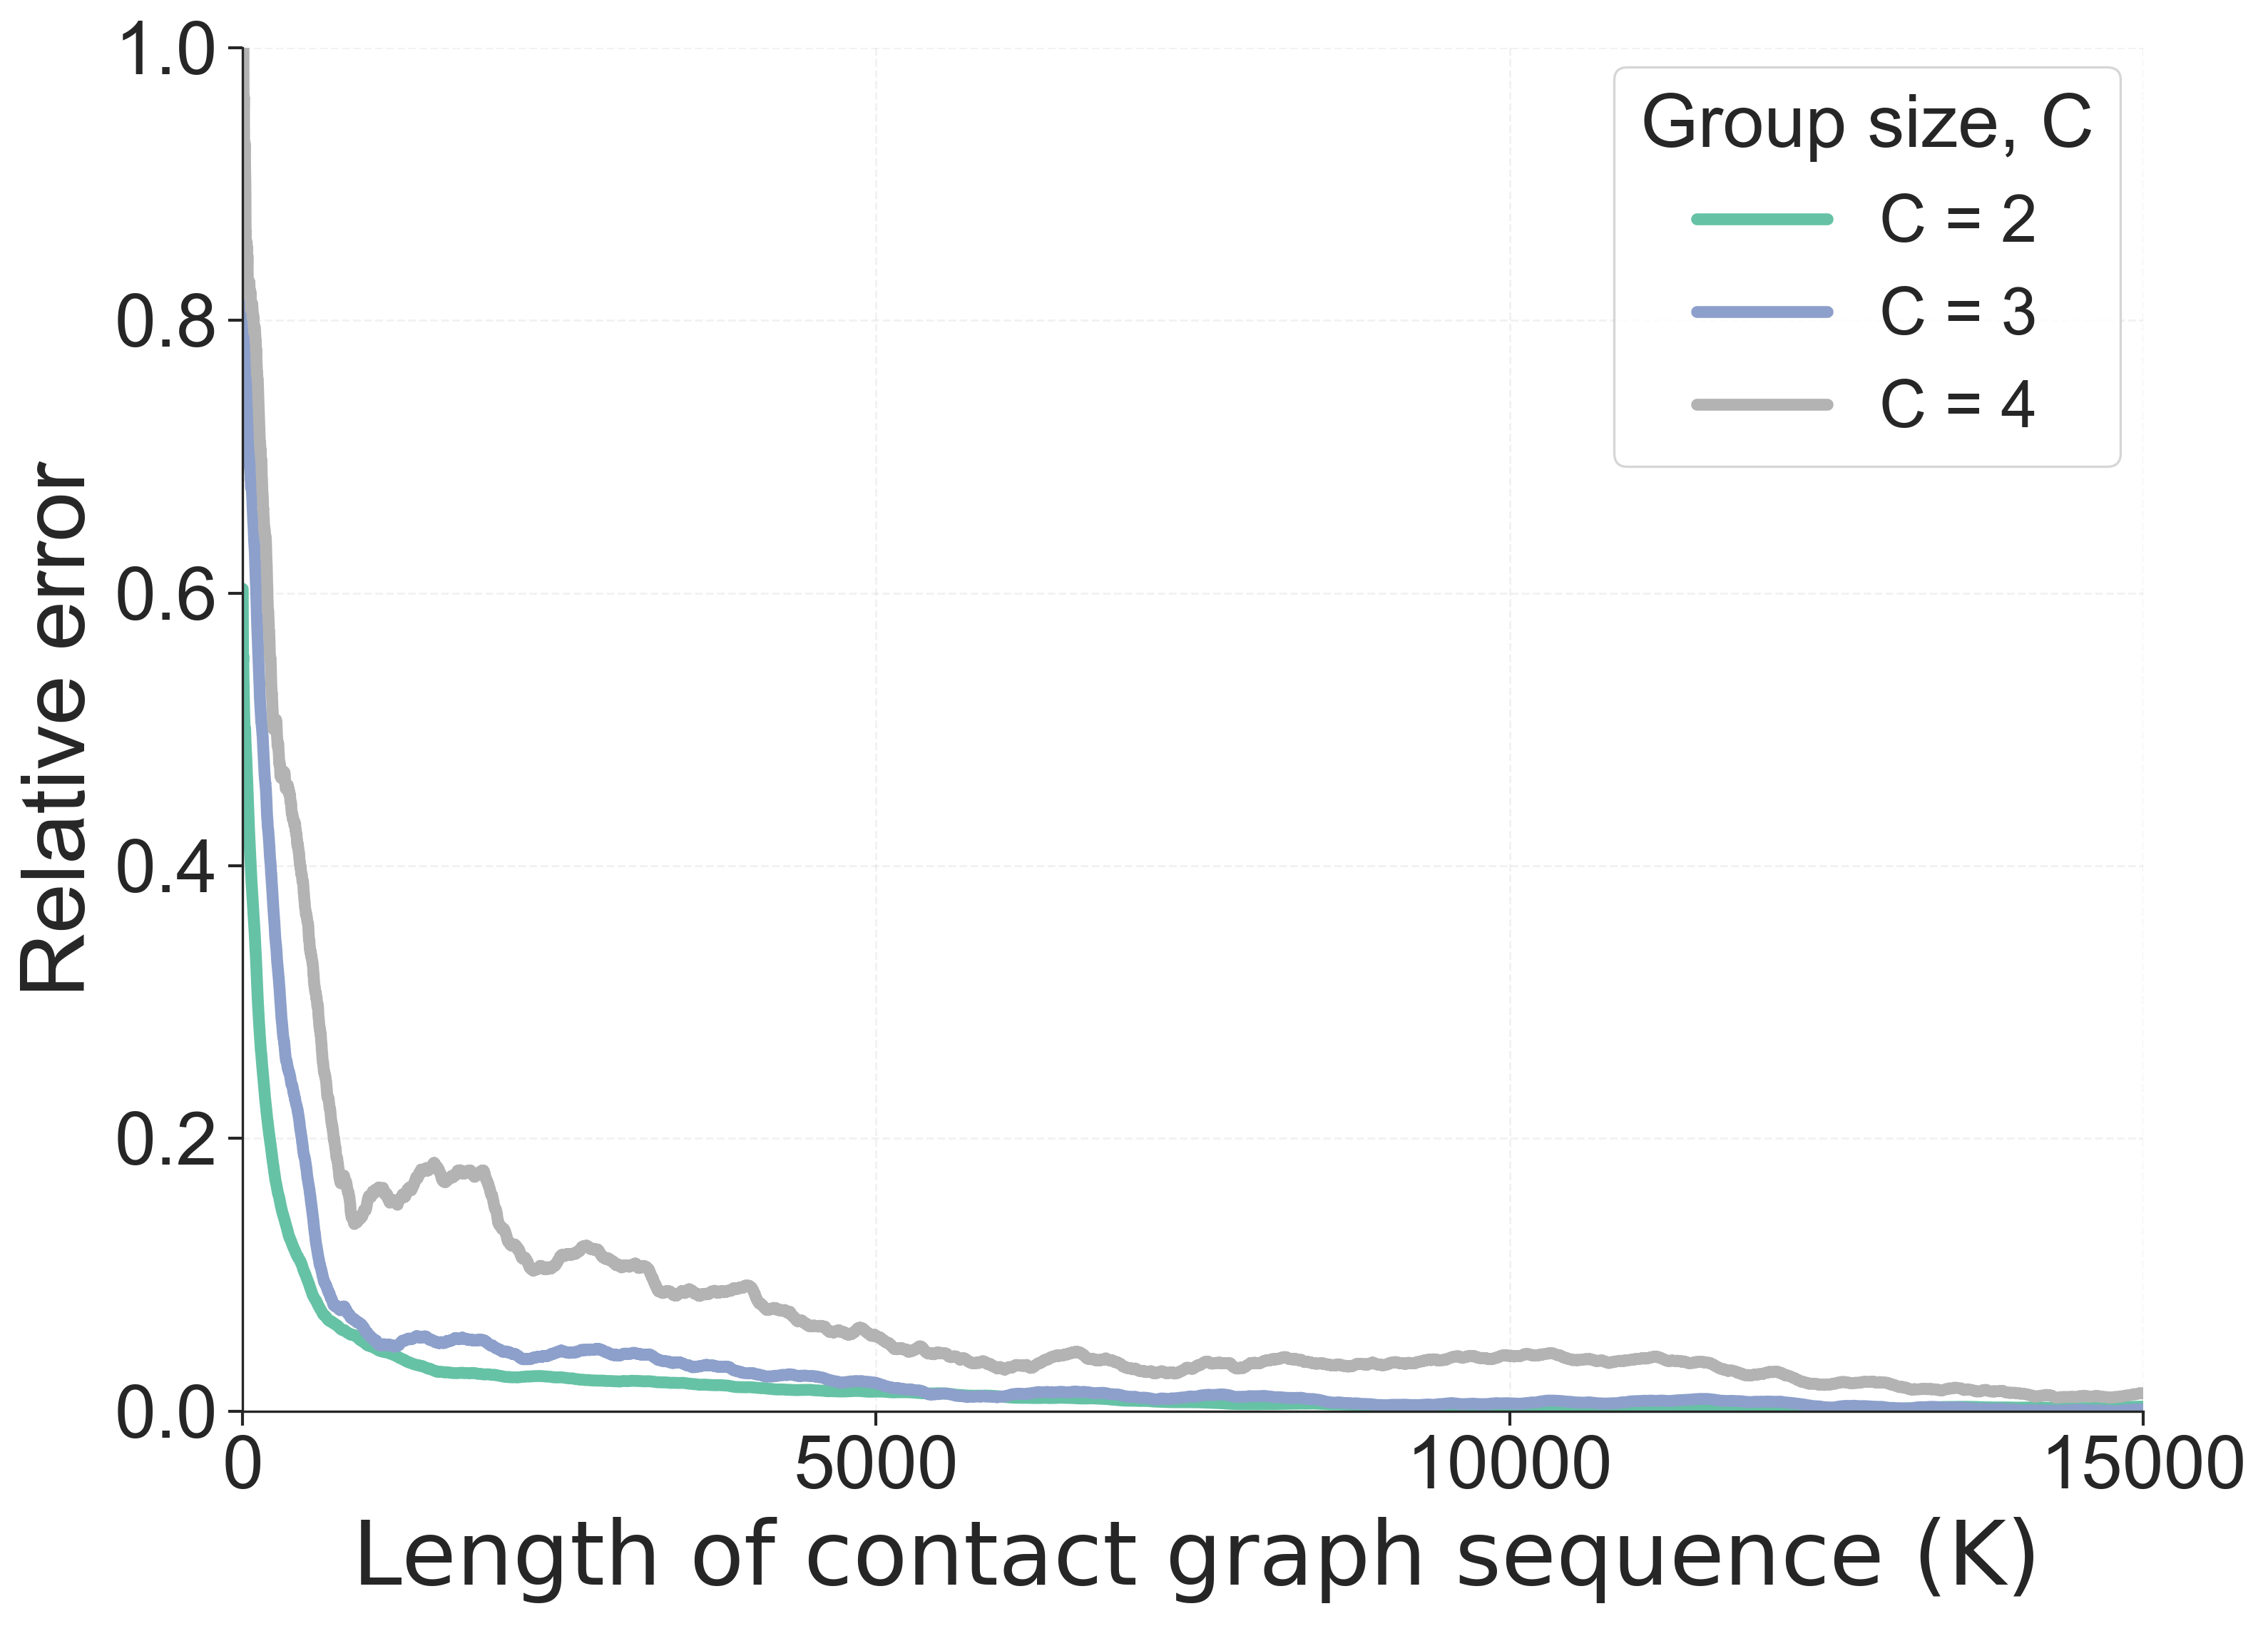

In [6]:
plot_contact_convergence(
    rel_error2,
    global_max=15000,
    filename="single_times_walkers.png",
)

### Consecutive-time contacts

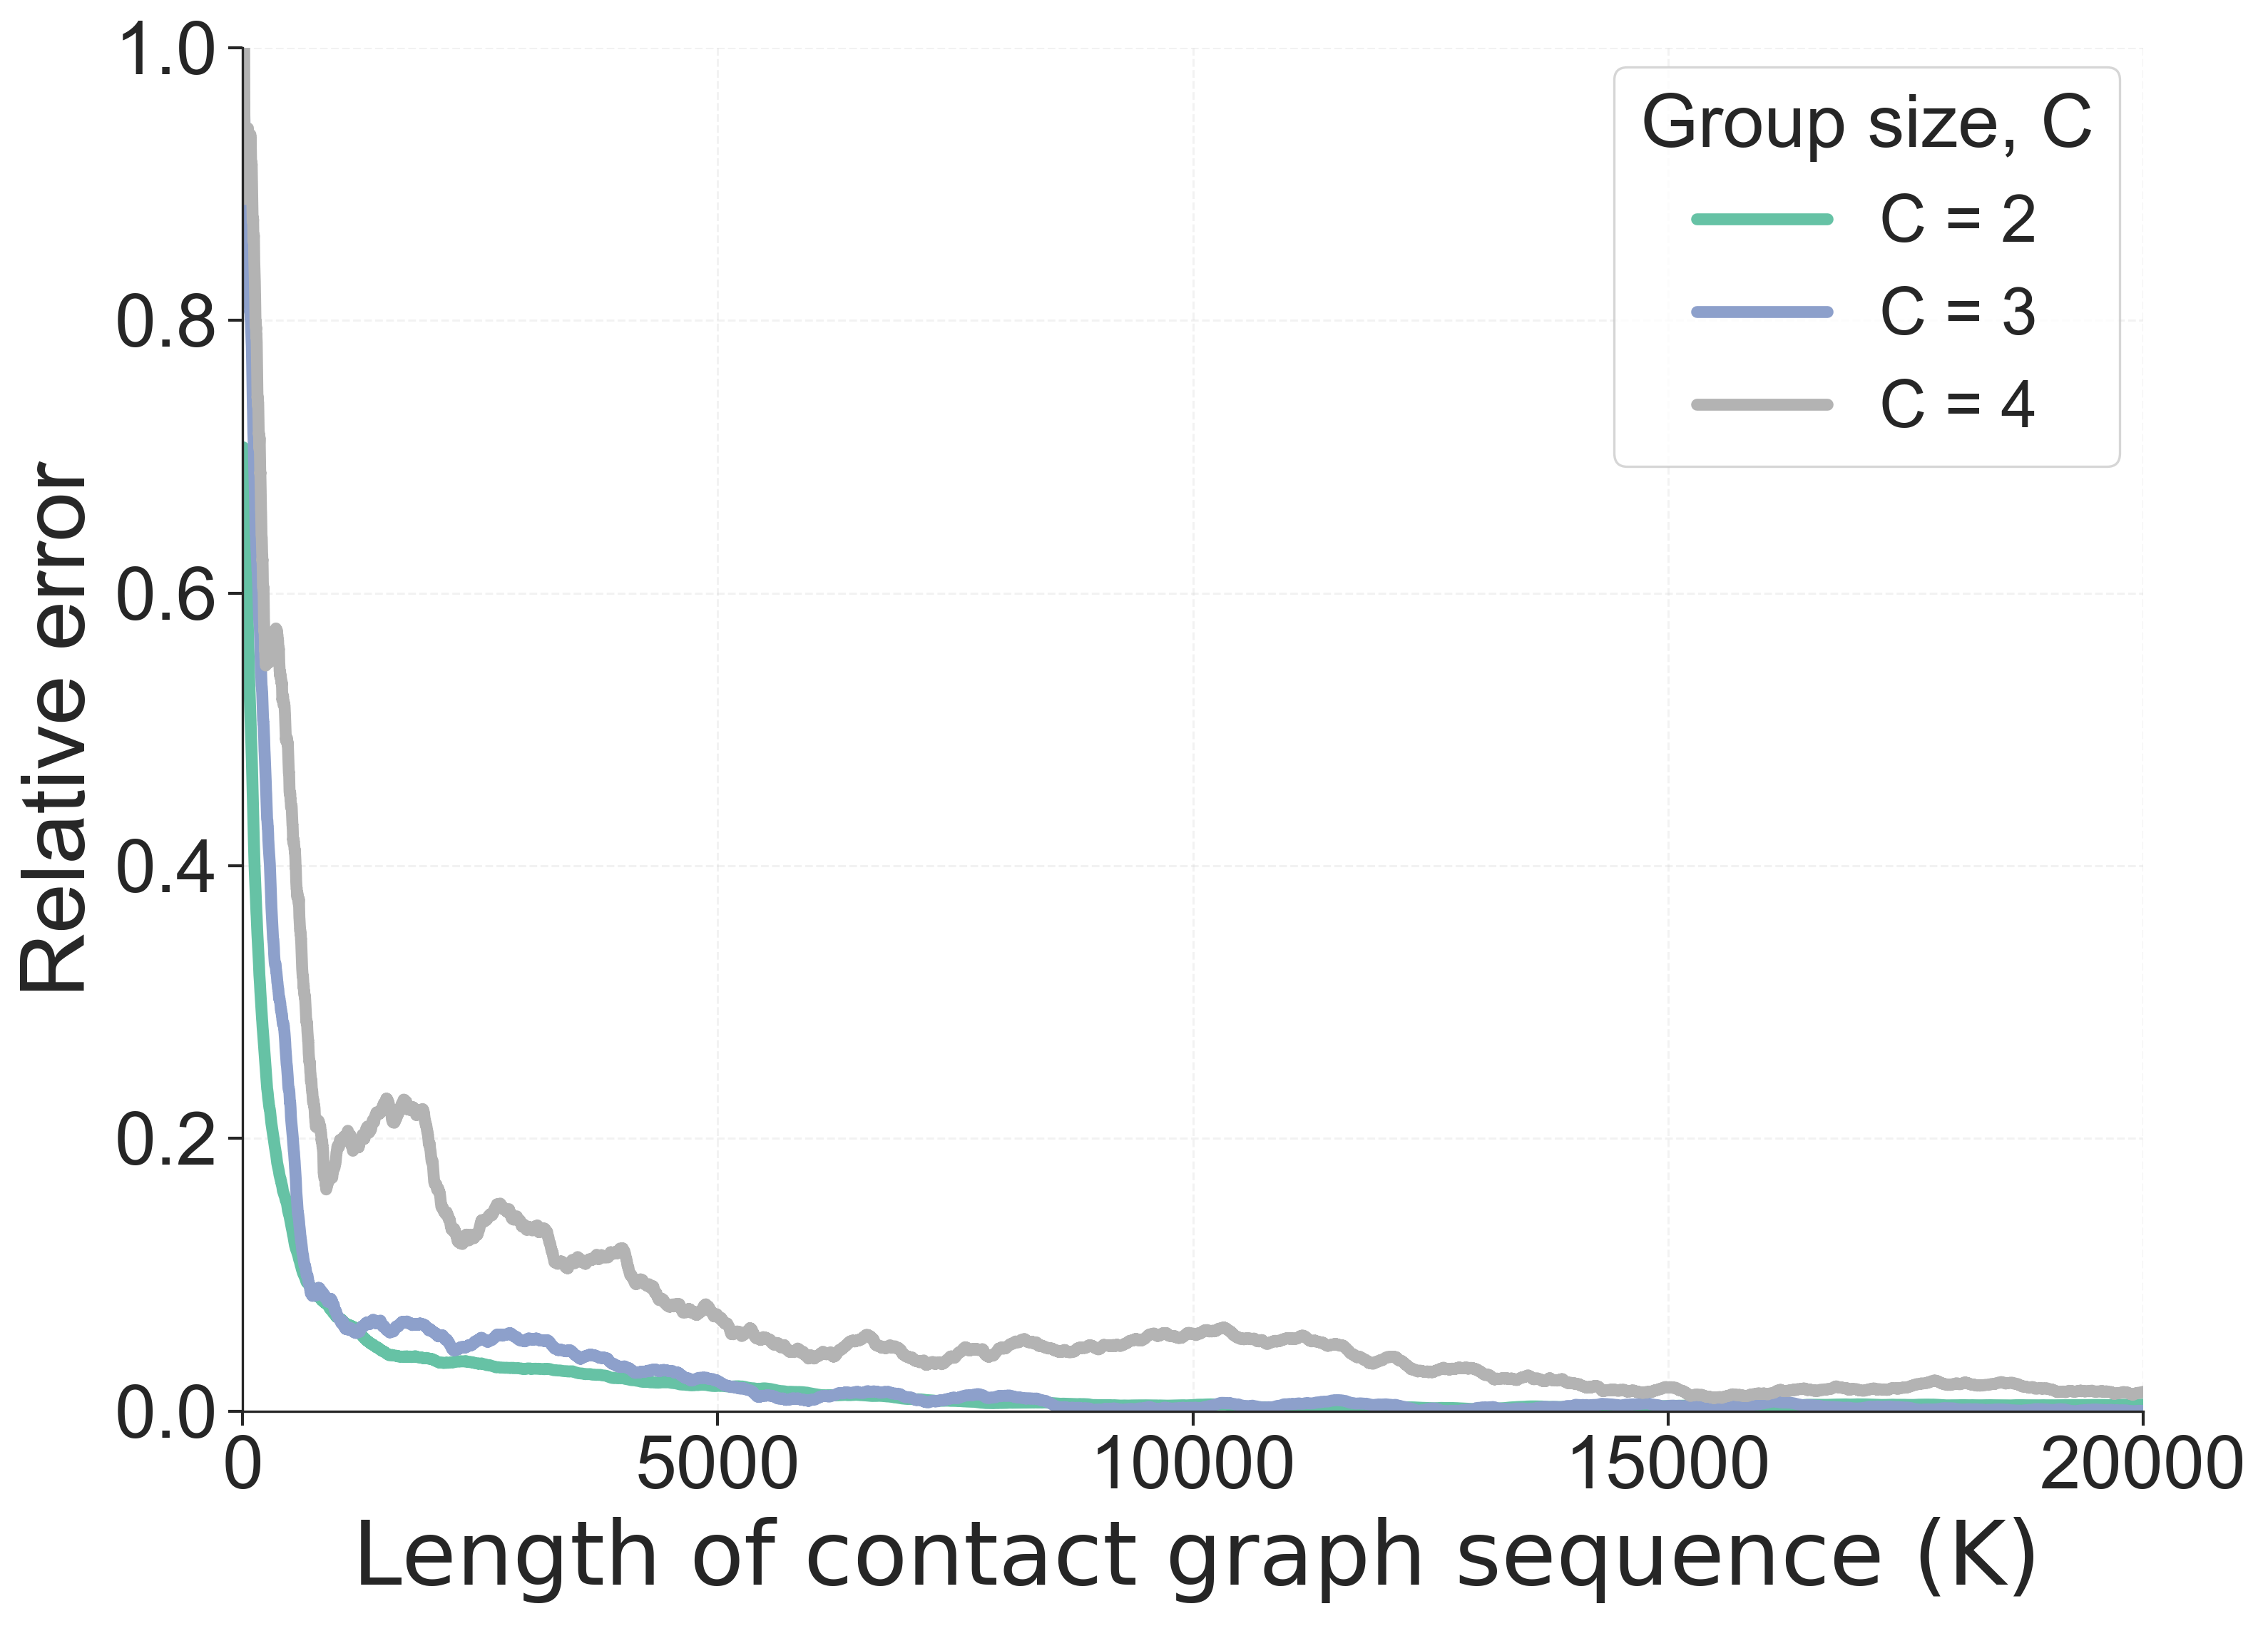

In [7]:
plot_contact_convergence(
    rel_error_joint2,
    global_max=20000,
    filename="consequtive_times_walkers.png",
)